In [1]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Solution", "Main"]' \
  --output ../exercises/D1-04_decision-tree.ipynb D1-04_decision-tree.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions/D1-04_decision-tree.ipynb D1-04_decision-tree.ipynb

[NbConvertApp] Converting notebook D1-04_decision-tree.ipynb to notebook
[NbConvertApp] Writing 298885 bytes to ../exercises/D1-04_decision-tree.ipynb
[NbConvertApp] Converting notebook D1-04_decision-tree.ipynb to notebook
[NbConvertApp] Writing 425905 bytes to ../solutions/D1-04_decision-tree.ipynb


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns

import sklearn

# Problem presentation
Same problem as the logistic regression, but we change the ML model used. We try to determine whether there is snow or not at the Folgefonna skisenter based on other weather variables.

# STEP 01 PREPROCESSING DATA
The data is loaded with pandas, a library allowing to extract data from csv table files.


## Load data from file
The numpy array are provided in X_data and y_data variables

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data/folgefonna-skisenter_vaeret.csv', index_col=0)
df=df.dropna()

In [3]:
X = df[['Tmin','wind','Pr','Tmax']].values
y = df[['Snowdepth']].values

We **binarize** the y data so it is 1 when the snow is above 0.1 and 0 otherwise.

In [4]:
y = sklearn.preprocessing.Binarizer(threshold=0.1).fit_transform(y).reshape(-1)

## **QUESTION 1**: Create train, validation and test datasets from `X` and `y`.

In [ ]:
X_train, X_valtest, y_train, y_valtest = ...
X_val, X_test, y_val, y_test = ...

In [5]:
X_train, X_valtest, y_train, y_valtest = sklearn.model_selection.train_test_split(X,y, train_size=0.7)
X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(X_valtest,y_valtest, train_size=0.7)

### Plot example data
We plot a subset of the data on a 2d space. The colors represent the presence of snow.

Text(39.858819444444435, 0.5, 'Wind')

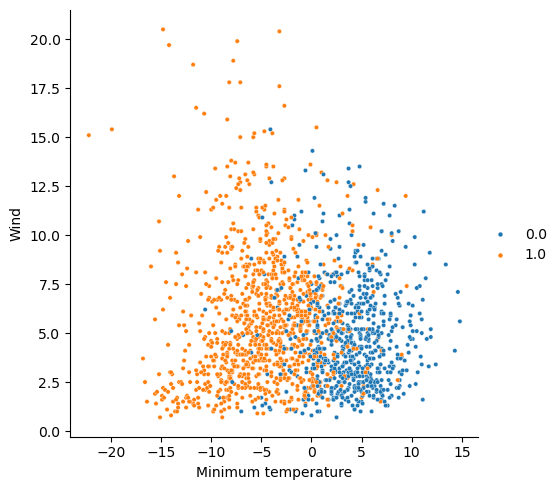

In [6]:
sns.relplot(x=X_train[:,0], 
            y=X_train[:,1],
            hue=y_train[:],
            s=10
           )
plt.xlabel('Minimum temperature')
plt.ylabel('Wind')

# STEP 2: Define ML model and fit it to the data


## **QUESTION 2**: Define the DecisionTree model by creating the object `model` in the following cell.
There is one hyperparameter we can change here: `max_depth`, it corresponds to the number of sequential splits that we do. Choose what you feel appropriate.

In [ ]:
max_depth = ...
model = ...

In [7]:
max_depth = 2
model = sklearn.tree.DecisionTreeClassifier(max_depth=max_depth)
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## Step 2.2: Fit the model to the data
Once we have defined the model, we will fit the model to the data. The model will change some internal coefficients to link the X and Y datasets.

## **QUESTION 3**: Fit the model to the **training data** in the following cell.

In [ ]:
...

In [9]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## Plot the tree

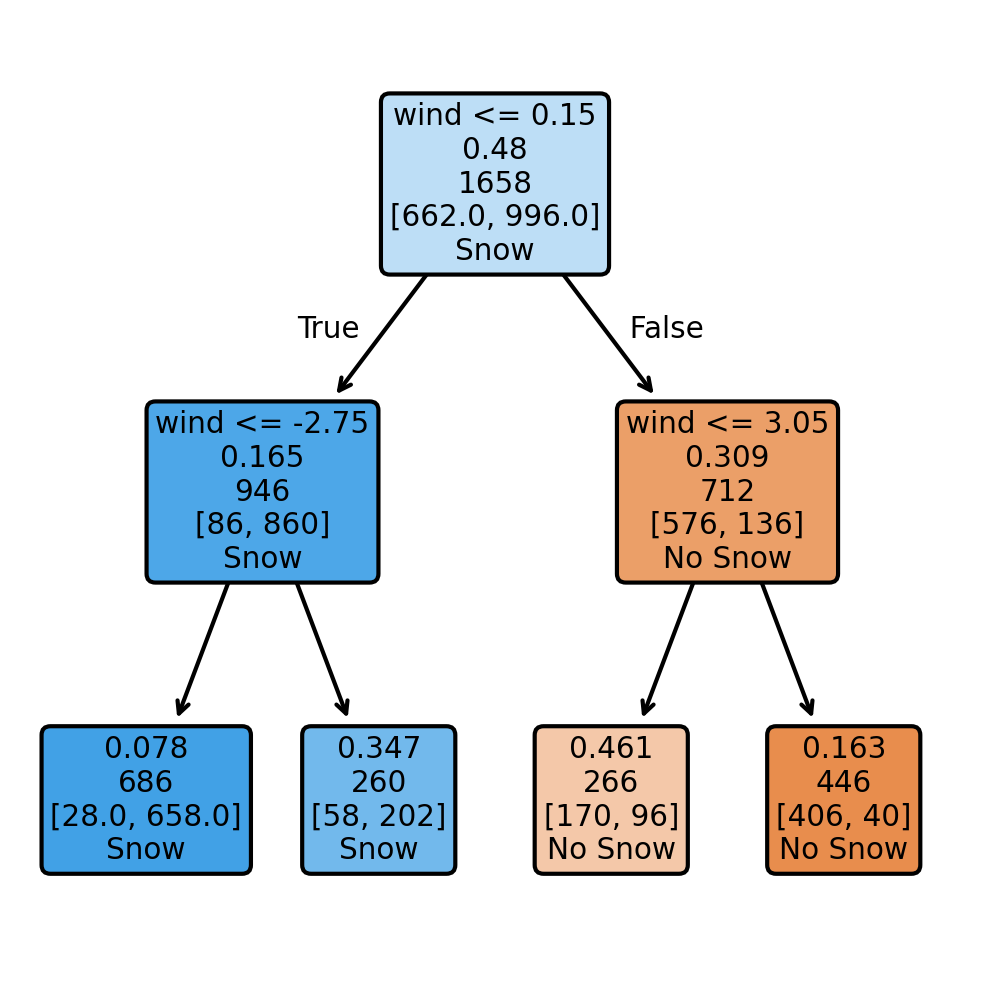

In [10]:
fig, ax = plt.subplots(figsize=(4,4), dpi=300)
sklearn.tree.plot_tree(model, 
                       feature_names=['wind','Pr','Tmax'],
                       filled=True, rounded=True,ax=ax, class_names=['No Snow','Snow'],
                       label='none');

# STEP 3: Make predictions and evaluate the model skill
Once the model is fitted to the data, we can use it to make predictions.

## Step 3.1: Predict `y` from `X`
We predict the values of `y` from `X` based on the relation learned by the model.

## **QUESTION 4**: Use the **validation data** to make predictions.

In [ ]:
y_val_predictions = ...

In [11]:
y_val_predictions = model.predict(X_val)

## Evaluate the results with `accuracy` and confusion matrix
We compute the confusion matrix and the accuracy

## **QUESTION 5**: Compute the confusion matrix of the validation data.

In [ ]:
confusion_matrix = ...

In [12]:
confusion_matrix = sklearn.metrics.confusion_matrix(y_val, y_val_predictions)

We now visualize the confusion matrix

[Text(0.5, 0, 'No Snow'), Text(1.5, 0, 'Snow')]

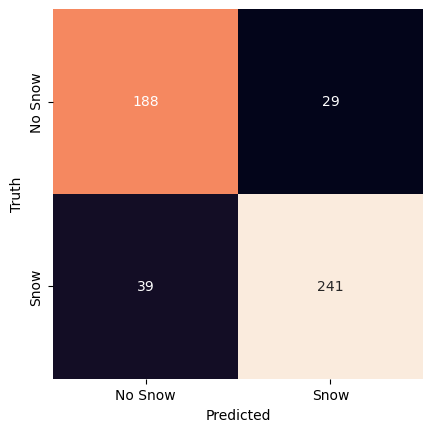

In [13]:
fig, ax = plt.subplots()
sns.heatmap(confusion_matrix, square=True, cbar=False, annot=True, fmt='.0f',ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Truth')
ax.set_yticklabels(['No Snow','Snow'])
ax.set_xticklabels(['No Snow','Snow'])

## **QUESTION 6**: Compute the accuracy of the model.

In [ ]:
accuracy = ...

print(f"Accuracy: {accuracy:.02f}")


In [14]:
accuracy = sklearn.metrics.accuracy_score(y_val, y_val_predictions)

print(f"Accuracy: {accuracy:.02f}")

Accuracy: 0.86


## **QUESTION 7**: Change the number of sequential splits and compare results.
Is there an optimal number of splits? You can plot the accuracy compared to the depth of the tree.

In [ ]:
...

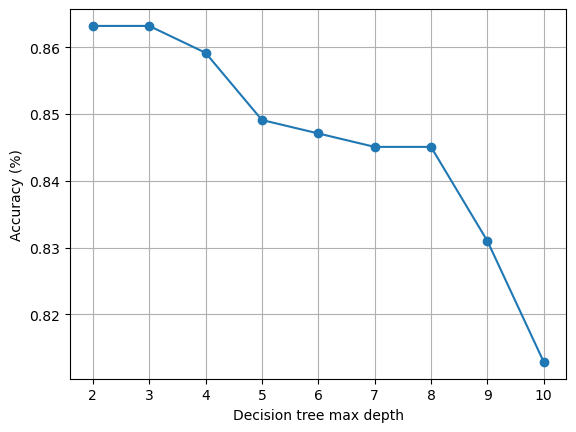

In [15]:
all_accuracy = []
for max_depth in range(2, 11):
    model = sklearn.tree.DecisionTreeClassifier(max_depth=max_depth)
    model.fit(X_train, y_train)
    y_val_predictions = model.predict(X_val)
    accuracy = sklearn.metrics.accuracy_score(y_val, y_val_predictions)
    all_accuracy.append(accuracy)

fig, ax = plt.subplots()
ax.plot(np.arange(2,11), all_accuracy, marker='o')
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Decision tree max depth')
ax.grid()

## **QUESTION 8**: Compare the performance with the logistic regression

In [ ]:
...

In [16]:
best_accuracy = max(all_accuracy)
model = sklearn.linear_model.LogisticRegression()
model.fit(X_train, y_train)
y_val_predictions = model.predict(X_val)
accuracy = sklearn.metrics.accuracy_score(y_val, y_val_predictions)

print(f"Best accuracy for decision tree {best_accuracy:.02f}")
print(f"Best accuracy for logisitic regression {accuracy:.02f}")


Best accuracy for decision tree 0.86
Best accuracy for logisitic regression 0.85
